# Système intelligent de prédiction des performances académiques des étudiants



## 1. Import des bibliothèques

In [43]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Style graphique
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


## 2. Collecte et chargement des données



In [44]:
FICHIER = "Dataset_UCI.xlsx"

df = pd.read_excel(FICHIER, sheet_name="Donnees")
doc = pd.read_excel(FICHIER, sheet_name="Documentation")

print(f"Dimensions du jeu de données : {df.shape[0]} étudiants, {df.shape[1]} variables")
df.head()

Dimensions du jeu de données : 4424 étudiants, 16 variables


,id_etudiant,sexe,age_entree,niveau_entree,niveau_etude_mere,niveau_etude_pere,statut_boursier,endettement,frais_a_jour,loin_domicile,moyenne_s1,taux_reussite_s1_pct,moyenne_s2,taux_reussite_s2_pct,resultat,risque_echec
0,1,M,20,Secondaire,Secondaire,Secondaire,Non,Non,Oui,Oui,0.00,0.0,0.00,0.0,Abandon,1
1,2,M,19,Secondaire,Secondaire,Superieur,Non,Non,Non,Oui,14.00,100.0,13.67,100.0,Diplome,0
2,3,M,19,Secondaire,Aucun/Primaire,Aucun/Primaire,Non,Non,Non,Oui,0.00,0.0,0.00,0.0,Abandon,1
3,4,F,20,Secondaire,Secondaire,Aucun/Primaire,Non,Non,Oui,Oui,13.43,100.0,12.40,83.3,Diplome,0
4,5,F,45,Secondaire,Aucun/Primaire,Secondaire,Non,Non,Oui,Non,12.33,83.3,13.00,100.0,Diplome,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_etudiant           4424 non-null   int64  
 1   sexe                  4424 non-null   object 
 2   age_entree            4424 non-null   int64  
 3   niveau_entree         4424 non-null   object 
 4   niveau_etude_mere     4424 non-null   object 
 5   niveau_etude_pere     4424 non-null   object 
 6   statut_boursier       4424 non-null   object 
 7   endettement           4424 non-null   object 
 8   frais_a_jour          4424 non-null   object 
 9   loin_domicile         4424 non-null   object 
 10  moyenne_s1            4424 non-null   float64
 11  taux_reussite_s1_pct  4424 non-null   float64
 12  moyenne_s2            4424 non-null   float64
 13  taux_reussite_s2_pct  4424 non-null   float64
 14  resultat              4424 non-null   object 
 15  risque_echec         

## 3. Analyse exploratoire des données (EDA)

### 3.1 Qualité des données

In [45]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

print(f"\nDoublons : {df.duplicated().sum()}")
print(f"\nStatistiques descriptives des variables numériques :")
df.describe().T

Valeurs manquantes par colonne :
id_etudiant             0
sexe                    0
age_entree              0
niveau_entree           0
niveau_etude_mere       0
niveau_etude_pere       0
statut_boursier         0
endettement             0
frais_a_jour            0
loin_domicile           0
moyenne_s1              0
taux_reussite_s1_pct    0
moyenne_s2              0
taux_reussite_s2_pct    0
resultat                0
risque_echec            0
dtype: int64

Doublons : 0

Statistiques descriptives des variables numériques :


,count,mean,std,min,25%,50%,75%,max
id_etudiant,4424.0,2212.500000,1277.243125,1.0,1106.75,2212.50,3318.25,4424.00
age_entree,4424.0,23.265145,7.587816,17.0,19.00,20.00,25.00,70.00
moyenne_s1,4424.0,10.640848,4.843666,0.0,11.00,12.29,13.40,18.88
taux_reussite_s1_pct,4424.0,69.786257,36.523180,0.0,50.00,83.30,100.00,100.00
moyenne_s2,4424.0,10.230201,5.210819,0.0,10.75,12.20,13.33,18.57
taux_reussite_s2_pct,4424.0,66.033770,38.295016,0.0,40.00,83.30,100.00,100.00
risque_echec,4424.0,0.321203,0.466991,0.0,0.00,0.00,1.00,1.00


### 3.2 Distribution de la variable cible

La variable cible retenue pour la prédiction du **risque d'échec** est `risque_echec` (1 = Abandon, 0 = sinon), dérivée de la variable `resultat` (Abandon / Inscrit / Diplômé).

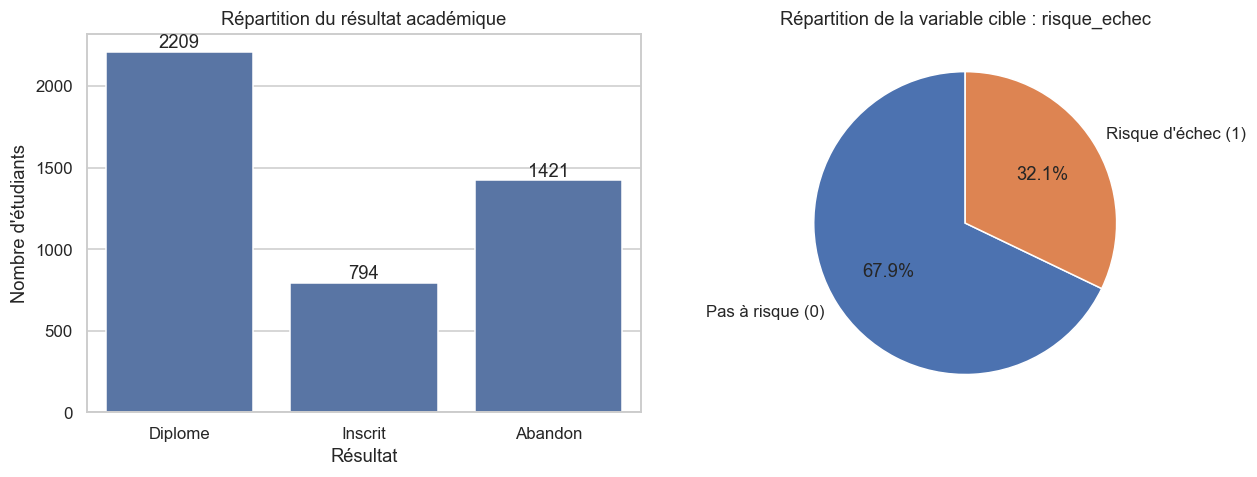

Proportion d'étudiants à risque d'échec (abandon) : 32.1%
=> Déséquilibre modéré des classes, à prendre en compte lors de la modélisation.


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Premier graphique : Barplot
order = ["Diplome", "Inscrit", "Abandon"]
sns.countplot(data=df, x="resultat", order=order, ax=axes[0])
axes[0].set_title("Répartition du résultat académique")
axes[0].set_xlabel("Résultat")
axes[0].set_ylabel("Nombre d'étudiants")

for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom")

# 2. Deuxième graphique : Pie chart
risque_counts = df["risque_echec"].value_counts()
axes[1].pie(risque_counts, labels=["Pas à risque (0)", "Risque d'échec (1)"],
            autopct="%1.1f%%", colors=sns.color_palette("deep")[:2], startangle=90)
axes[1].set_title("Répartition de la variable cible : risque_echec")

plt.tight_layout()

# SAUVEGARDE EN PREMIER (300 DPI pour une qualité parfaite dans Word)
plt.savefig("distribution_variables_cibles.png", dpi=300, bbox_inches="tight")

# AFFICHAGE EN SECOND
plt.show()

# Calcul et affichage des statistiques
taux = df["risque_echec"].mean() * 100
print(f"Proportion d'étudiants à risque d'échec (abandon) : {taux:.1f}%")
print("=> Déséquilibre modéré des classes, à prendre en compte lors de la modélisation.")

### 3.3 Variables numériques académiques (moyennes et taux de réussite)

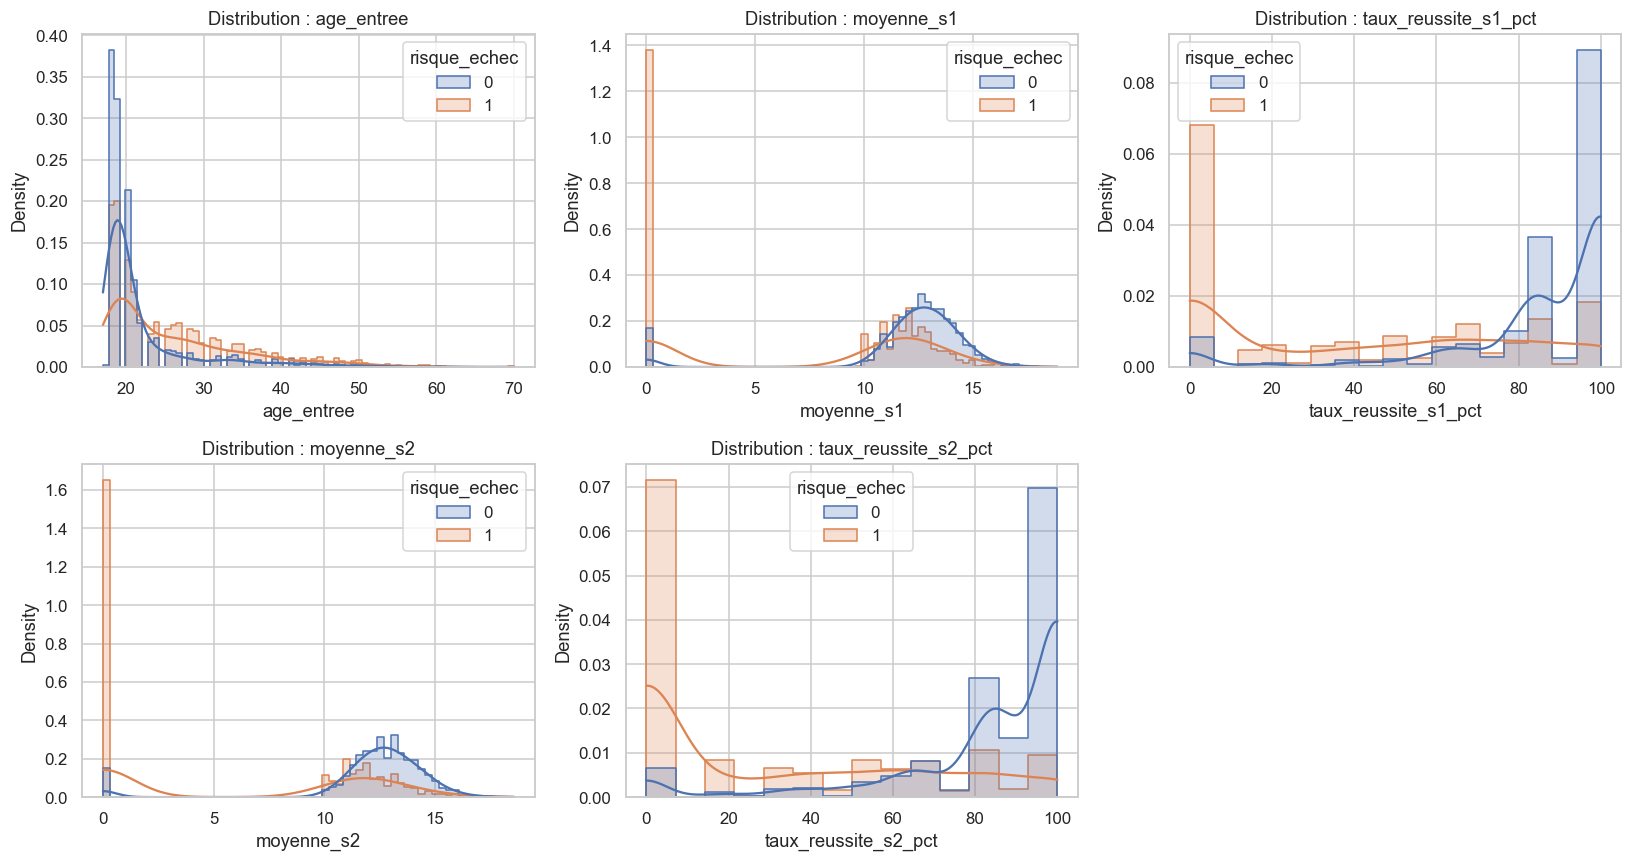

In [49]:
num_cols = ["age_entree", "moyenne_s1", "taux_reussite_s1_pct", "moyenne_s2", "taux_reussite_s2_pct"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="risque_echec", kde=True, ax=axes[i],
                 palette="deep", element="step", stat="density", common_norm=False)
    axes[i].set_title(f"Distribution : {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

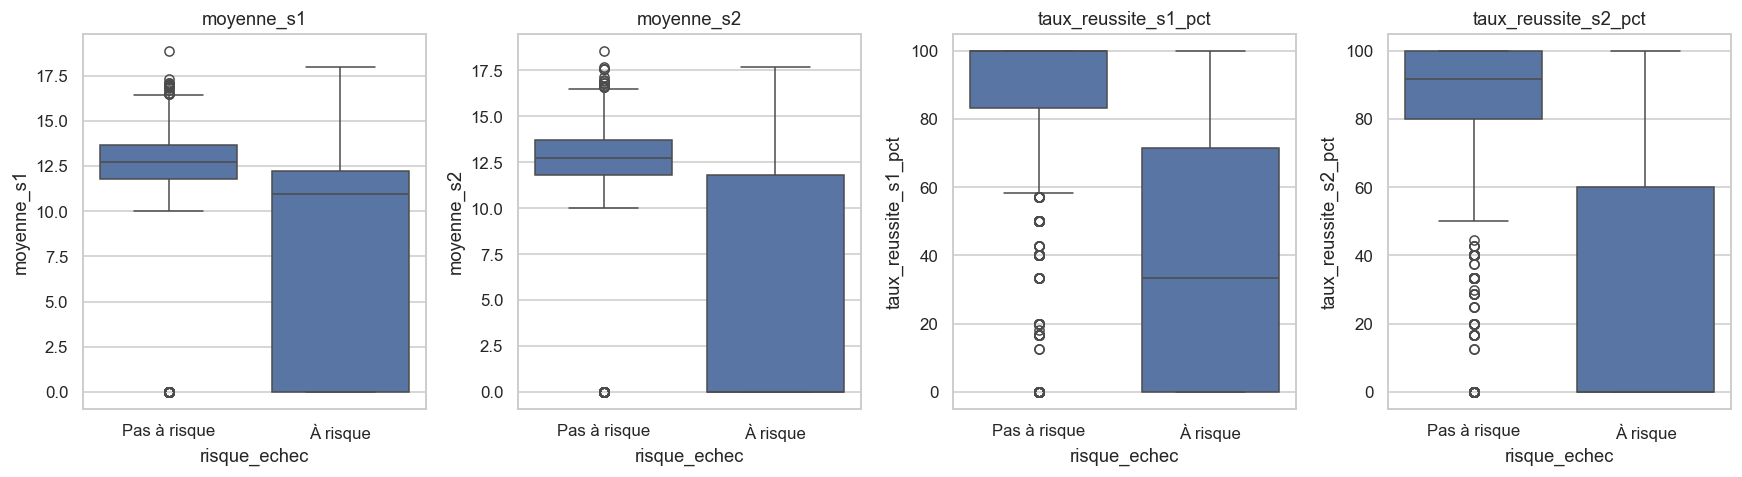

Les moyennes et taux de réussite du 1er et 2e semestre se distinguent nettement
entre les étudiants à risque et les autres : ce sont a priori des variables très prédictives.


In [50]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
box_cols = ["moyenne_s1", "moyenne_s2", "taux_reussite_s1_pct", "taux_reussite_s2_pct"]
for i, col in enumerate(box_cols):
    sns.boxplot(data=df, x="risque_echec", y=col, ax=axes[i])
    axes[i].set_xticklabels(["Pas à risque", "À risque"])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

print("Les moyennes et taux de réussite du 1er et 2e semestre se distinguent nettement")
print("entre les étudiants à risque et les autres : ce sont a priori des variables très prédictives.")

### 3.4 Variables catégorielles (profil socio-démographique)

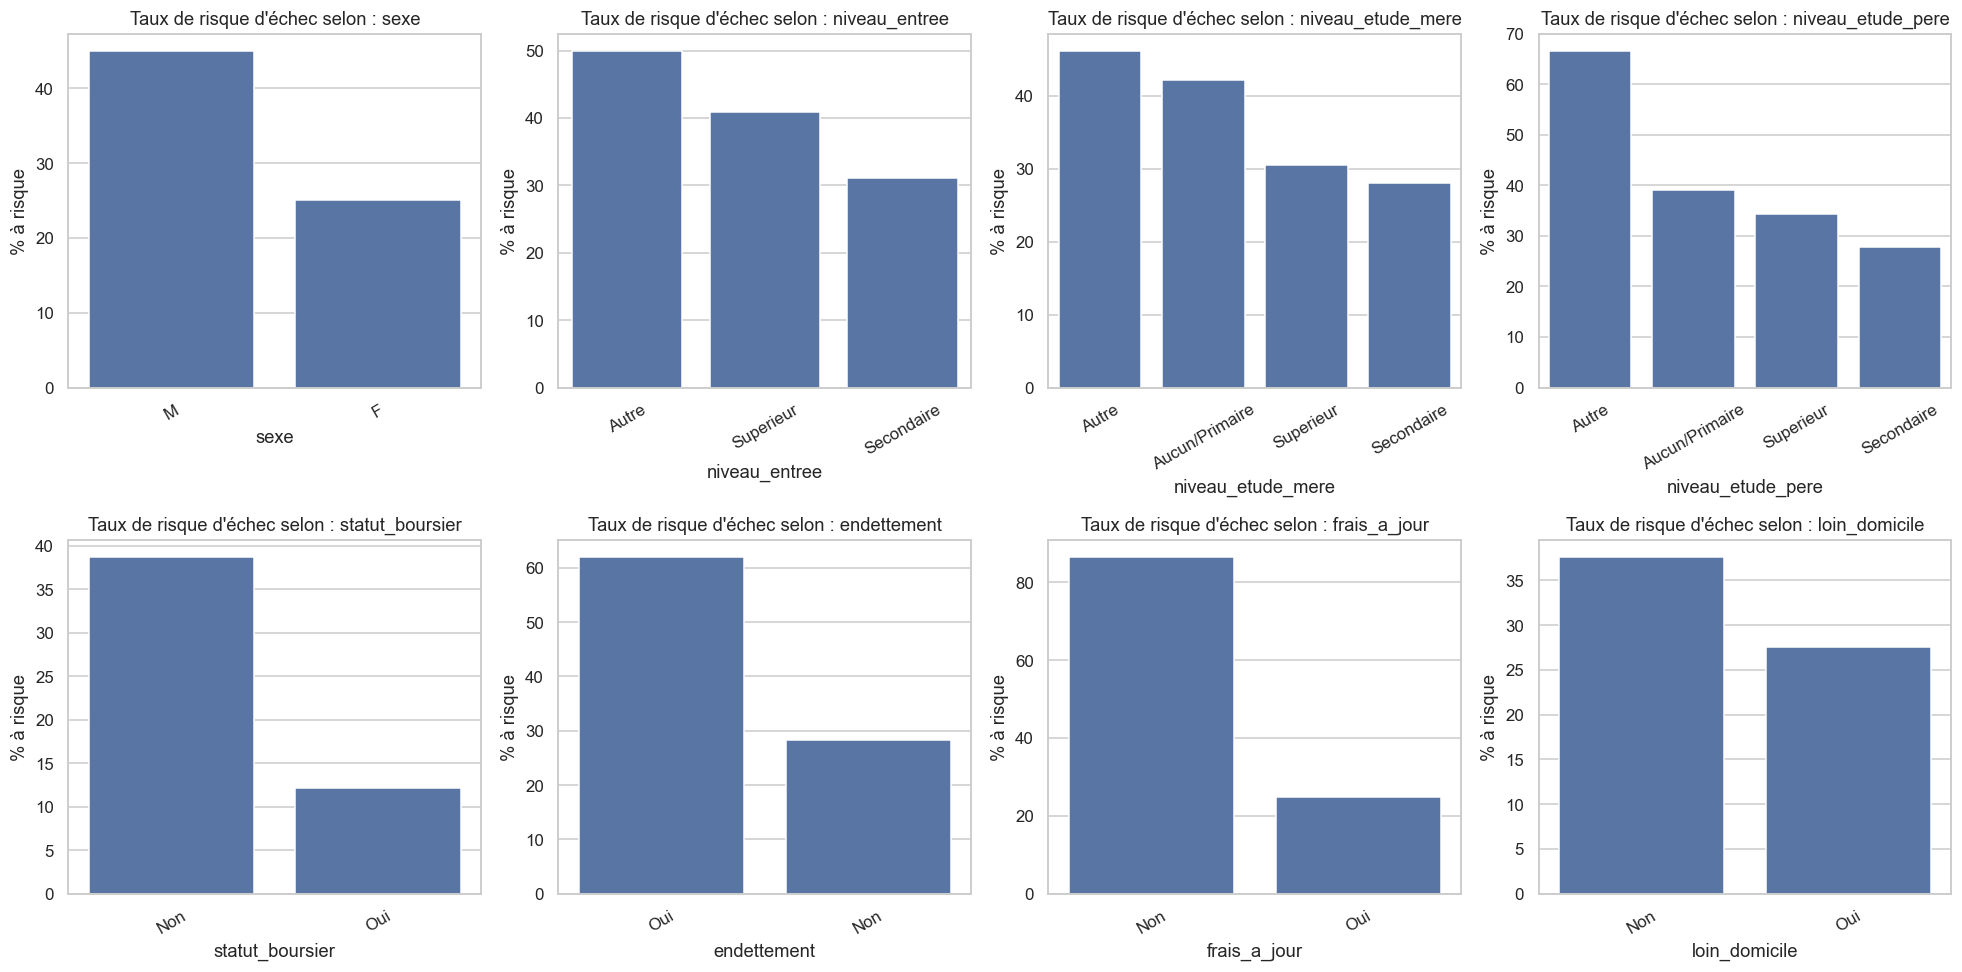

In [51]:
cat_cols = ["sexe", "niveau_entree", "niveau_etude_mere", "niveau_etude_pere",
            "statut_boursier", "endettement", "frais_a_jour", "loin_domicile"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    taux_risque = df.groupby(col)["risque_echec"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=taux_risque.index, y=taux_risque.values, ax=axes[i])
    axes[i].set_title(f"Taux de risque d'échec selon : {col}")
    axes[i].set_ylabel("% à risque")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 3.5 Matrice de corrélation (variables numériques)

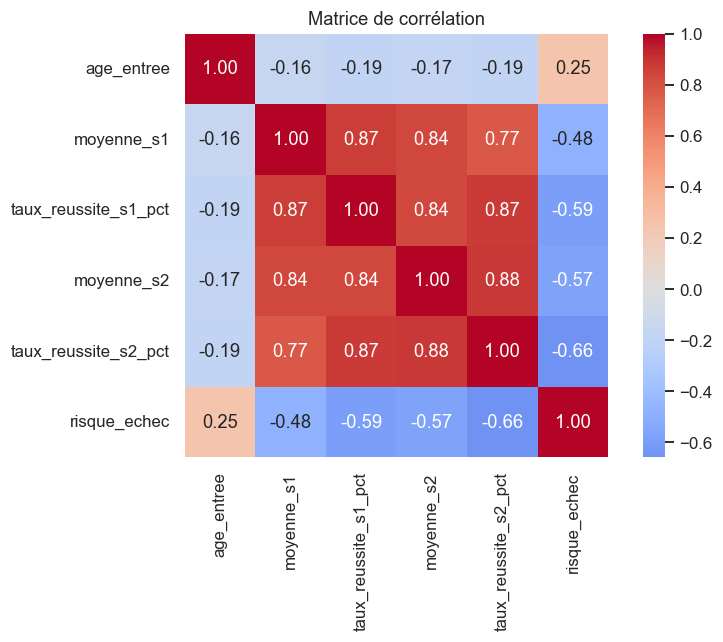

In [52]:
corr_cols = num_cols + ["taux_reussite_s1_pct", "taux_reussite_s2_pct", "risque_echec"]
corr_cols = list(dict.fromkeys(corr_cols))  # dédoublonnage en conservant l'ordre
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## 4. Prétraitement des données


1. Séparation variables explicatives (X) / variable cible (y).
2. Encodage des variables qualitatives (One-Hot Encoding).
3. Séparation train / test stratifiée (80% / 20%).
4. Normalisation (standardisation) des variables quantitatives.
5. Analyse du déséquilibre des classes.

L'identifiant `id_etudiant` et la variable `resultat` (source directe de la cible, donc fuite de donnée / *data leakage*) sont exclus des variables explicatives.

In [53]:
# Variables explicatives et cible
cible = "risque_echec"
colonnes_exclues = ["id_etudiant", "resultat", cible]

X = df.drop(columns=colonnes_exclues)
y = df[cible]

variables_numeriques = ["age_entree", "moyenne_s1", "taux_reussite_s1_pct",
                         "moyenne_s2", "taux_reussite_s2_pct"]
variables_categorielles = ["sexe", "niveau_entree", "niveau_etude_mere", "niveau_etude_pere",
                            "statut_boursier", "endettement", "frais_a_jour", "loin_domicile"]

print(f"Nombre de variables explicatives : {X.shape[1]}")
print(f"  - numériques    : {len(variables_numeriques)}")
print(f"  - catégorielles : {len(variables_categorielles)}")

Nombre de variables explicatives : 13
  - numériques    : 5
  - catégorielles : 8


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} étudiants")
print(f"Ensemble de test        : {X_test.shape[0]} étudiants")
print(f"\nTaux de risque (train) : {y_train.mean()*100:.1f}%")
print(f"Taux de risque (test)  : {y_test.mean()*100:.1f}%")

Ensemble d'entraînement : 3539 étudiants
Ensemble de test        : 885 étudiants

Taux de risque (train) : 32.1%
Taux de risque (test)  : 32.1%


In [55]:
# Pipeline de prétraitement : standardisation des numériques + one-hot des catégorielles
preprocesseur = ColumnTransformer(transformers=[
    ("num", StandardScaler(), variables_numeriques),
    ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), variables_categorielles),
])

print("Préprocesseur défini : StandardScaler (numériques) + OneHotEncoder (catégorielles).")

Préprocesseur défini : StandardScaler (numériques) + OneHotEncoder (catégorielles).


### 4.1 Gestion du déséquilibre des classes



## 5. Modélisation : comparaison de plusieurs algorithmes de Machine Learning

- **Régression Logistique** (modèle de référence, linéaire, interprétable)
- **Arbre de décision**
- **Random Forest**
- **XGBoost**
- **SVM** (noyau RBF)
- **Réseau de neurones artificiel (ANN / MLP)**

Chaque modèle est intégré dans un pipeline avec le préprocesseur, puis évalué par **validation croisée stratifiée à 5 plis** sur l'ensemble d'entraînement, avant une évaluation finale sur l'ensemble de test.

In [56]:
modeles = {
    "Regression Logistique": LogisticRegression(max_iter=1000, class_weight="balanced",
                                                 random_state=RANDOM_STATE),
    "Arbre de Decision": DecisionTreeClassifier(max_depth=6, class_weight="balanced",
                                                 random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10,
                                             class_weight="balanced", random_state=RANDOM_STATE,
                                             n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              eval_metric="logloss", random_state=RANDOM_STATE,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced",
                      random_state=RANDOM_STATE),
    "Reseau de Neurones (ANN)": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500,
                                               random_state=RANDOM_STATE),
}

print(f"{len(modeles)} modèles à comparer :", list(modeles.keys()))

6 modèles à comparer : ['Regression Logistique', 'Arbre de Decision', 'Random Forest', 'XGBoost', 'SVM (RBF)', 'Reseau de Neurones (ANN)']


In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc"}

resultats_cv = []
pipelines_entraines = {}

for nom, modele in modeles.items():
    pipe = Pipeline([("prep", preprocesseur), ("clf", modele)])

    # Validation croisée sur le train
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    # Entraînement final sur tout le train, évaluation sur le test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    pipelines_entraines[nom] = pipe

    resultats_cv.append({
        "Modele": nom,
        "CV_Accuracy": scores["test_accuracy"].mean(),
        "CV_F1": scores["test_f1"].mean(),
        "CV_AUC": scores["test_roc_auc"].mean(),
        "Test_Accuracy": accuracy_score(y_test, y_pred),
        "Test_Precision": precision_score(y_test, y_pred),
        "Test_Recall": recall_score(y_test, y_pred),
        "Test_F1": f1_score(y_test, y_pred),
        "Test_AUC": roc_auc_score(y_test, y_proba),
    })
    print(f"[OK] {nom} entraîné et évalué.")

resultats_df = pd.DataFrame(resultats_cv).sort_values("Test_F1", ascending=False).reset_index(drop=True)

[OK] Regression Logistique entraîné et évalué.
[OK] Arbre de Decision entraîné et évalué.
[OK] Random Forest entraîné et évalué.
[OK] XGBoost entraîné et évalué.
[OK] SVM (RBF) entraîné et évalué.
[OK] Reseau de Neurones (ANN) entraîné et évalué.


### 5.1 Tableau comparatif des performances

In [58]:
resultats_df.style.background_gradient(cmap="Greens", subset=[c for c in resultats_df.columns if c != "Modele"]).format(precision=3)

,Modele,CV_Accuracy,CV_F1,CV_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,Random Forest,0.856,0.773,0.907,0.878,0.808,0.813,0.811,0.924
1,SVM (RBF),0.851,0.777,0.901,0.870,0.777,0.835,0.805,0.915
2,Regression Logistique,0.845,0.770,0.901,0.867,0.769,0.835,0.801,0.923
3,XGBoost,0.843,0.765,0.897,0.858,0.755,0.824,0.788,0.918
4,Reseau de Neurones (ANN),0.843,0.747,0.886,0.864,0.804,0.764,0.783,0.908
5,Arbre de Decision,0.833,0.752,0.861,0.844,0.723,0.835,0.775,0.906


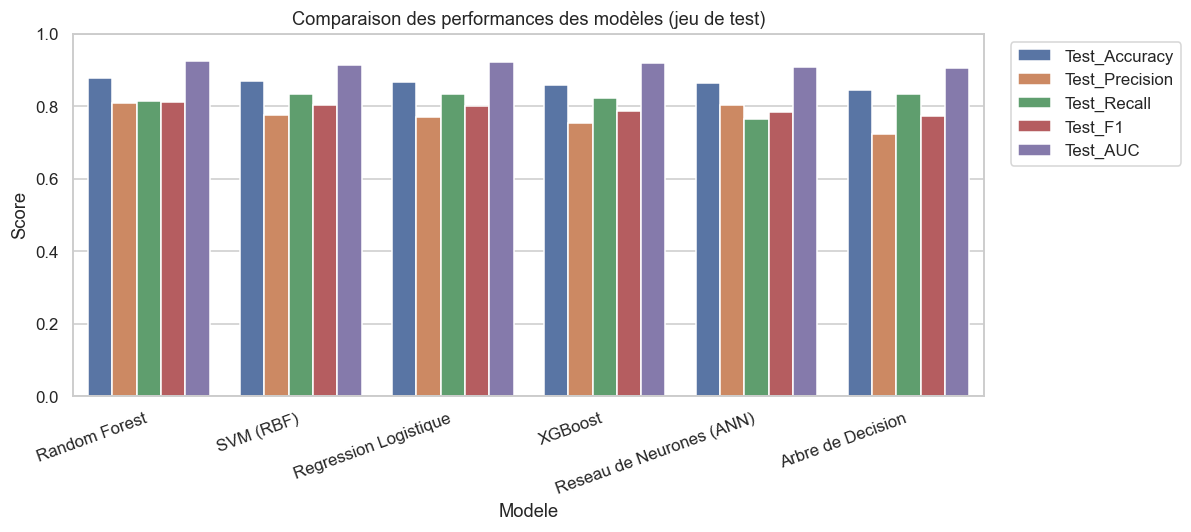

In [59]:
fig, ax = plt.subplots(figsize=(11, 5))
metriques_affichees = ["Test_Accuracy", "Test_Precision", "Test_Recall", "Test_F1", "Test_AUC"]
resultats_melt = resultats_df.melt(id_vars="Modele", value_vars=metriques_affichees,
                                    var_name="Metrique", value_name="Score")
sns.barplot(data=resultats_melt, x="Modele", y="Score", hue="Metrique", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Comparaison des performances des modèles (jeu de test)")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.2 Matrices de confusion

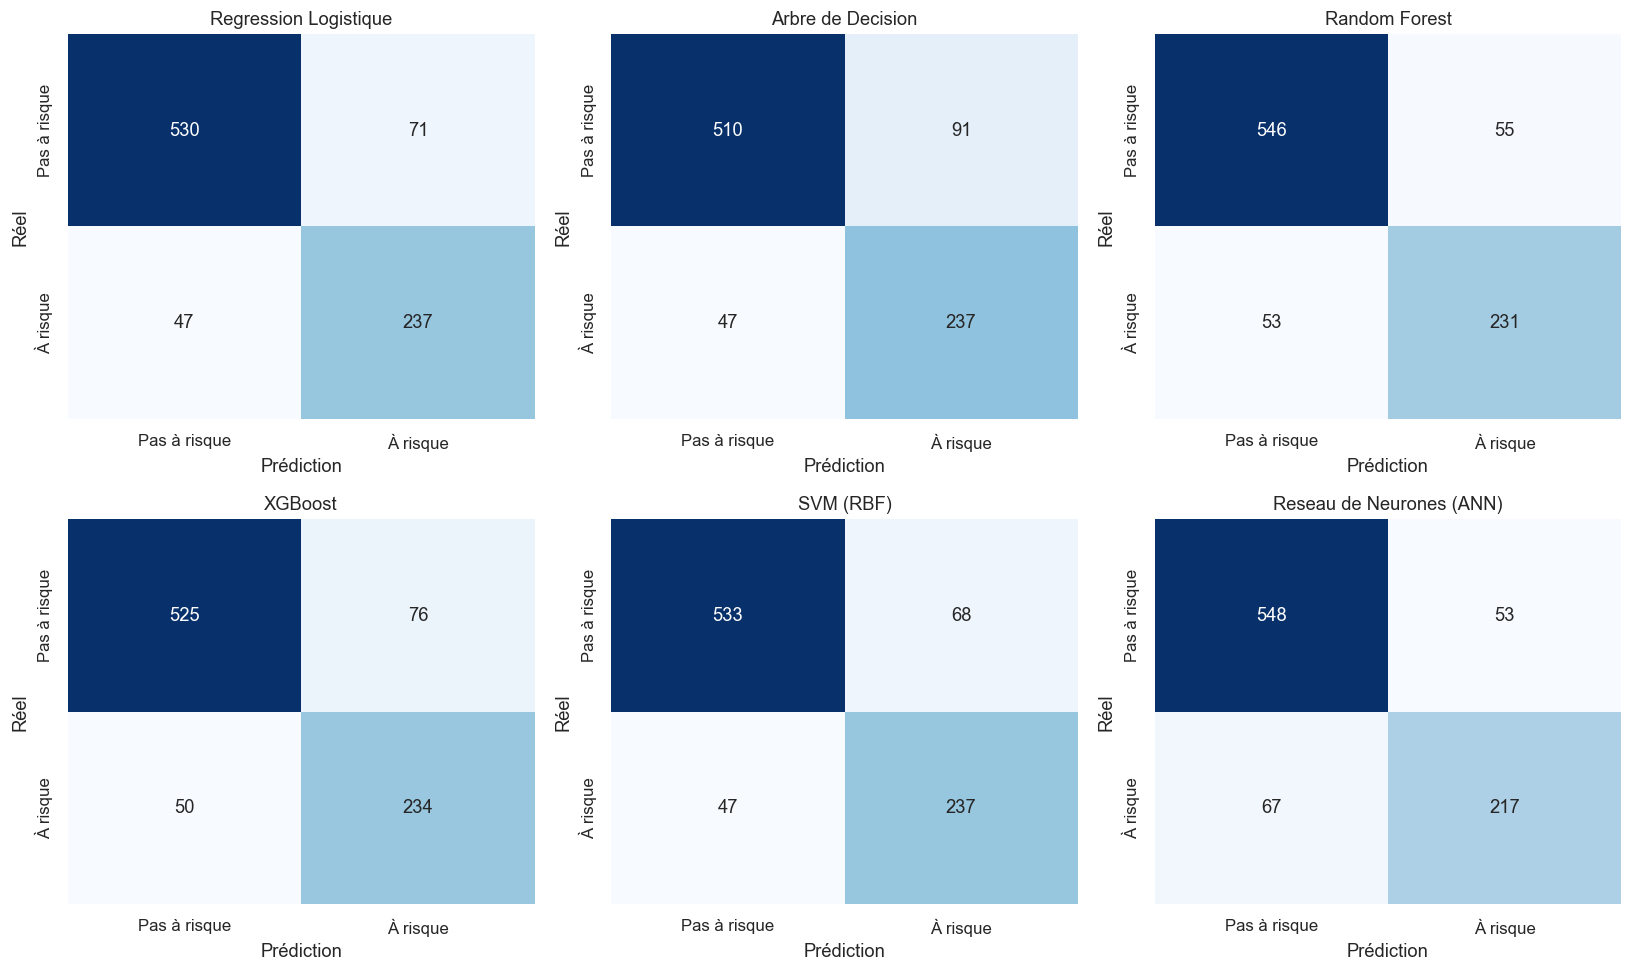

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (nom, pipe) in enumerate(pipelines_entraines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], cbar=False,
                xticklabels=["Pas à risque", "À risque"],
                yticklabels=["Pas à risque", "À risque"])
    axes[i].set_title(nom)
    axes[i].set_xlabel("Prédiction")
    axes[i].set_ylabel("Réel")

plt.tight_layout()
plt.show()

### 5.3 Courbes ROC comparées

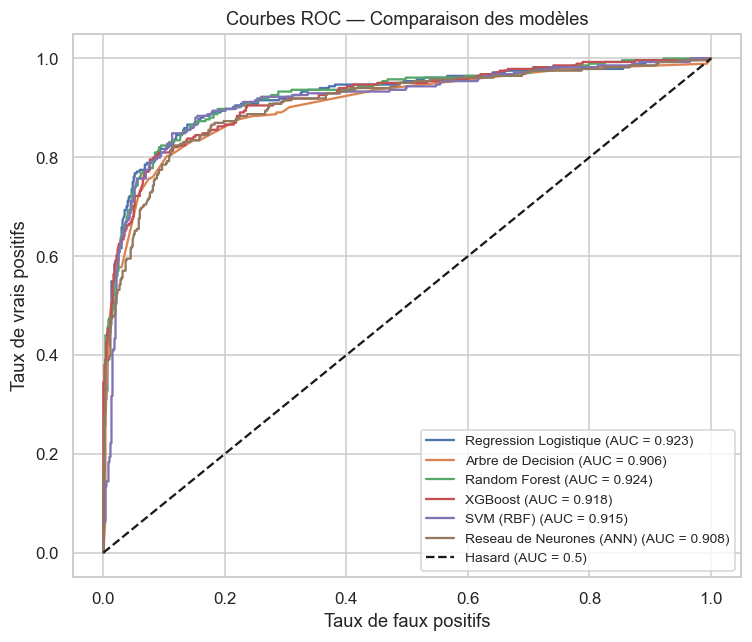

In [61]:
plt.figure(figsize=(7, 6))
for nom, pipe in pipelines_entraines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — Comparaison des modèles")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Optimisation du meilleur modèle (recherche d'hyperparamètres)

Le modèle affichant le meilleur compromis F1 / AUC sur le jeu de test est sélectionné pour une phase d'optimisation par `GridSearchCV`.

In [62]:
meilleur_modele_nom = resultats_df.iloc[0]["Modele"]
print(f"Meilleur modèle sélectionné pour optimisation : {meilleur_modele_nom}")

Meilleur modèle sélectionné pour optimisation : Random Forest


In [66]:
# Grille d'hyperparamètres pour Random Forest et XGBoost (les 2 candidats les plus probables)
grilles = {
    "Random Forest": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [6, 10, 14, None],
        "clf__min_samples_leaf": [1, 2, 5],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
    "Regression Logistique": {
        "clf__C": [0.01, 0.1, 1, 10],
    },
    "SVM (RBF)": {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", "auto"],
    },
    "Arbre de Decision": {
        "clf__max_depth": [4, 6, 8, 10],
        "clf__min_samples_leaf": [1, 2, 5],
    },
    "Reseau de Neurones (ANN)": {
        "clf__hidden_layer_sizes": [(16,), (32, 16), (64, 32)],
        "clf__alpha": [0.0001, 0.001, 0.01],
    },
}

pipe_base = Pipeline([("prep", preprocesseur), ("clf", modeles[meilleur_modele_nom])])
grille = grilles[meilleur_modele_nom]

grid_search = GridSearchCV(pipe_base, grille, scoring="f1", cv=cv, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)
print(f"Meilleur score F1 (validation croisée) : {grid_search.best_score_:.3f}")

Meilleurs hyperparamètres trouvés :
{'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 500}
Meilleur score F1 (validation croisée) : 0.781


In [64]:
modele_final = grid_search.best_estimator_
y_pred_final = modele_final.predict(X_test)
y_proba_final = modele_final.predict_proba(X_test)[:, 1]

print(f"=== Performance finale du modèle optimisé ({meilleur_modele_nom}) sur le jeu de test ===\n")
print(classification_report(y_test, y_pred_final, target_names=["Pas à risque", "À risque"]))
print(f"AUC : {roc_auc_score(y_test, y_proba_final):.3f}")

=== Performance finale du modèle optimisé (Random Forest) sur le jeu de test ===

              precision    recall  f1-score   support

Pas à risque       0.91      0.91      0.91       601
    À risque       0.81      0.82      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885

AUC : 0.924


## 7. Interprétation : importance des variables

Identification des facteurs les plus influents sur la prédiction du risque d'échec 

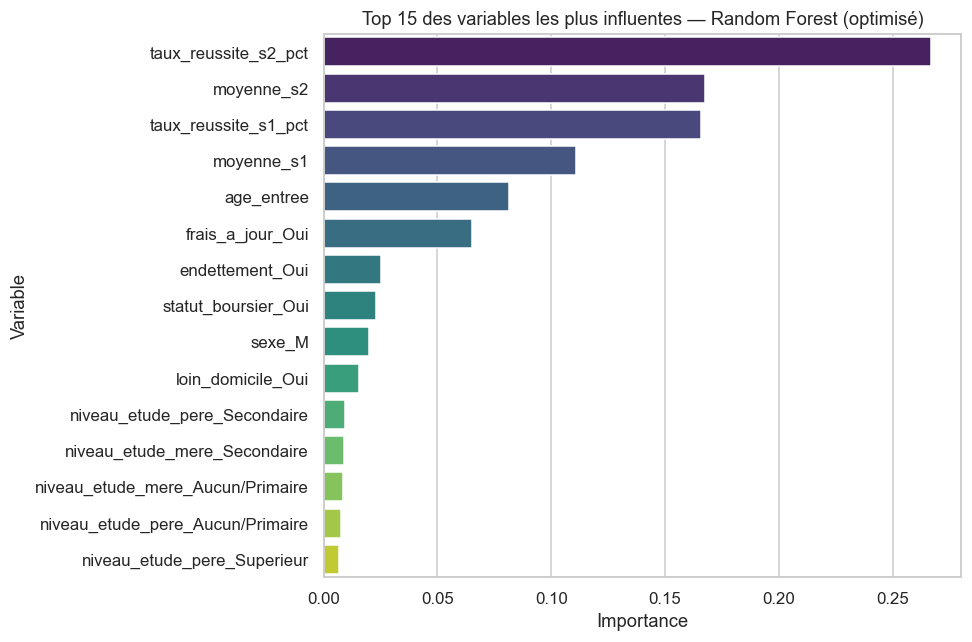

In [65]:
# Récupération des noms de variables après encodage
noms_num = variables_numeriques
noms_cat = list(modele_final.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(variables_categorielles))
noms_variables = noms_num + noms_cat

clf_final = modele_final.named_steps["clf"]

if hasattr(clf_final, "feature_importances_"):
    importances = clf_final.feature_importances_
elif hasattr(clf_final, "coef_"):
    importances = np.abs(clf_final.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"Variable": noms_variables, "Importance": importances})
    imp_df = imp_df.sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=imp_df, x="Importance", y="Variable", palette="viridis")
    plt.title(f"Top 15 des variables les plus influentes — {meilleur_modele_nom} (optimisé)")
    plt.tight_layout()
    plt.show()

    imp_df
else:
    print("Le modèle sélectionné ne fournit pas directement d'importance de variables interprétable.")

## 8. Système d'aide à la décision

Mise en place d'un mécanisme opérationnel destiné aux responsables pédagogiques :


In [68]:
def attribuer_niveau_risque(proba):
    if proba < 0.30:
        return "Faible"
    elif proba < 0.60:
        return "Modere"
    else:
        return "Eleve"

def recommandation(niveau):
    reco = {
        "Faible": "Suivi standard. Aucune action particulière requise.",
        "Modere": "Entretien de suivi conseillé avec le tuteur pédagogique ; "
                  "surveiller l'assiduité et les résultats du semestre suivant.",
        "Eleve": "Alerte prioritaire : convocation recommandée, mise en place d'un "
                 "plan de remédiation (tutorat renforcé, révision du parcours, "
                 "accompagnement social/financier si pertinent).",
    }
    return reco[niveau]

# Application au jeu de test
tableau_risque = X_test.copy()
tableau_risque["id_etudiant"] = df.loc[X_test.index, "id_etudiant"].values
tableau_risque["risque_reel"] = y_test.values
tableau_risque["score_risque_pct"] = (y_proba_final * 100).round(1)
tableau_risque["niveau_risque"] = [attribuer_niveau_risque(p) for p in y_proba_final]
tableau_risque["recommandation"] = tableau_risque["niveau_risque"].map(recommandation)

tableau_risque = tableau_risque.sort_values("score_risque_pct", ascending=False)

colonnes_affichees = ["id_etudiant", "moyenne_s1", "moyenne_s2", "taux_reussite_s1_pct",
                       "taux_reussite_s2_pct", "score_risque_pct", "niveau_risque",
                       "risque_reel", "recommandation"]

print("=== Top 10 des étudiants les plus à risque (jeu de test) ===")
tableau_risque[colonnes_affichees].head(10)

=== Top 10 des étudiants les plus à risque (jeu de test) ===


,id_etudiant,moyenne_s1,moyenne_s2,taux_reussite_s1_pct,taux_reussite_s2_pct,score_risque_pct,niveau_risque,risque_reel,recommandation
2748,2749,0.0,0.0,0.0,0.0,99.9,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
711,712,0.0,0.0,0.0,0.0,99.9,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
1539,1540,0.0,0.0,0.0,0.0,99.9,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
3533,3534,0.0,0.0,0.0,0.0,99.9,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
2021,2022,0.0,0.0,0.0,0.0,99.8,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
972,973,0.0,0.0,0.0,0.0,99.8,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
1548,1549,0.0,0.0,0.0,0.0,99.8,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
513,514,0.0,0.0,0.0,0.0,99.7,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
2711,2712,0.0,0.0,0.0,0.0,99.7,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."
689,690,0.0,0.0,0.0,0.0,99.6,Eleve,1,"Alerte prioritaire : convocation recommandée, ..."


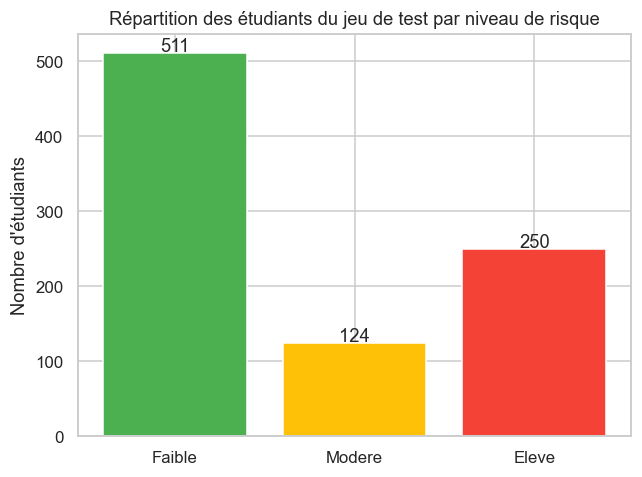

niveau_risque
Faible    511
Modere    124
Eleve     250
Name: count, dtype: int64


In [69]:
# Répartition des étudiants par niveau de risque
repartition = tableau_risque["niveau_risque"].value_counts().reindex(["Faible", "Modere", "Eleve"])

plt.figure(figsize=(6, 4.5))
couleurs = {"Faible": "#4CAF50", "Modere": "#FFC107", "Eleve": "#F44336"}
plt.bar(repartition.index, repartition.values, color=[couleurs[n] for n in repartition.index])
plt.title("Répartition des étudiants du jeu de test par niveau de risque")
plt.ylabel("Nombre d'étudiants")
for i, v in enumerate(repartition.values):
    plt.text(i, v + 2, str(v), ha="center")
plt.tight_layout()
plt.savefig("Répartition des étudiants par niveaux.png", dpi=300, bbox_inches="tight")
plt.show()


print(repartition)

In [70]:
def rapport_etudiant(id_etudiant):
    ligne = tableau_risque[tableau_risque["id_etudiant"] == id_etudiant]
    if ligne.empty:
        print("Étudiant introuvable dans le jeu de test.")
        return
    r = ligne.iloc[0]
    print(f"--- Rapport automatique — Étudiant #{id_etudiant} ---")
    print(f"Score de risque d'échec estimé : {r['score_risque_pct']}%")
    print(f"Niveau de risque : {r['niveau_risque']}")
    print(f"Moyenne S1 / S2 : {r['moyenne_s1']} / {r['moyenne_s2']}")
    print(f"Taux de réussite S1 / S2 : {r['taux_reussite_s1_pct']}% / {r['taux_reussite_s2_pct']}%")
    print(f"Recommandation : {r['recommandation']}")

# Exemple d'utilisation sur l'étudiant le plus à risque du classement
rapport_etudiant(int(tableau_risque.iloc[0]["id_etudiant"]))

--- Rapport automatique — Étudiant #2749 ---
Score de risque d'échec estimé : 99.9%
Niveau de risque : Eleve
Moyenne S1 / S2 : 0.0 / 0.0
Taux de réussite S1 / S2 : 0.0% / 0.0%
Recommandation : Alerte prioritaire : convocation recommandée, mise en place d'un plan de remédiation (tutorat renforcé, révision du parcours, accompagnement social/financier si pertinent).
